# Vision-Driven Multi-Agent Traffic Signal Control
## Notebook 3 -- Multi-Intersection MARL with MAPPO
---
**Goal**: Scale from 1 intersection to a 3x3 grid (9 intersections, 9 agents).
Implement and compare two MARL strategies:
- Independent PPO (IPPO): each agent trains independently, ignoring neighbours
- MAPPO: agents share a centralised critic that sees the global state

**What this notebook builds**:
1. A 3x3 SUMO grid network (9 traffic lights, 36 incoming lanes)
2. A multi-agent Gymnasium environment (one action/observation per intersection)
3. IPPO training baseline
4. MAPPO implementation with shared global critic
5. Robustness evaluation under three traffic scenarios
6. Final comparison plots


In [3]:

import subprocess, sys, os

print('Installing SUMO...')
subprocess.run('pip install -q eclipse-sumo traci sumolib', shell=True, check=True)
subprocess.run("pip install -q 'stable-baselines3[extra]' gymnasium matplotlib pandas tqdm torch",
               shell=True, check=True)

import sumo as _sumo_pkg
os.environ['SUMO_HOME'] = _sumo_pkg.SUMO_HOME
sys.path.append(os.path.join(_sumo_pkg.SUMO_HOME, 'tools'))

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import xml.etree.ElementTree as ET
import json
import time
import copy
from collections import defaultdict

import traci
import sumolib
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", DeprecationWarning)
import torch
import torch.nn as nn
import torch.optim as optim

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import CheckpointCallback, BaseCallback
from stable_baselines3.common.vec_env import DummyVecEnv

print('SUMO_HOME =', os.environ['SUMO_HOME'])
print('PyTorch   =', torch.__version__)
print('All imports successful.')

NET_DIR = '/content/sumo_grid'
os.makedirs(NET_DIR, exist_ok=True)

def write_xml(root, path):
    try:
        ET.indent(root, space='    ')
    except AttributeError:
        pass
    ET.ElementTree(root).write(path, encoding='unicode')


Installing SUMO...
SUMO_HOME = /usr/local/lib/python3.12/dist-packages/sumo
PyTorch   = 2.10.0+cpu
All imports successful.


In [4]:
# ============================================================
# BUILD 3x3 GRID NETWORK
#
# Layout (row, col) -- 0-indexed:
#
#   [N0]  [N1]  [N2]        <- north entry nodes
#    |     |     |
#   I00 - I01 - I02         <- row 0 intersections
#    |     |     |
#   I10 - I11 - I12         <- row 1 intersections
#    |     |     |
#   I20 - I21 - I22         <- row 2 intersections
#    |     |     |
#   [S0]  [S1]  [S2]        <- south entry nodes
#
#   [W0,W1,W2] on left,  [E0,E1,E2] on right
#
# Each intersection is a traffic light.
# Each arm is 200m, 2 lanes, 50 km/h.
# ============================================================
NET_DIR = '/content/sumo_grid'
SPACING = 200
GRID    = 3

nodes = ET.Element('nodes')

for r in range(GRID):
    for c in range(GRID):
        x = c * SPACING
        y = r * SPACING
        ET.SubElement(nodes, 'node',
                      id=f'I{r}{c}', x=str(x), y=str(y),
                      type='traffic_light')

for c in range(GRID):
    x = c * SPACING
    ET.SubElement(nodes, 'node', id=f'N{c}',
                  x=str(x), y=str(SPACING),    type='priority')
    ET.SubElement(nodes, 'node', id=f'S{c}',
                  x=str(x), y=str(-(SPACING)), type='priority')
for r in range(GRID):
    y = r * SPACING
    ET.SubElement(nodes, 'node', id=f'W{r}',
                  x=str(-(SPACING)), y=str(y), type='priority')
    ET.SubElement(nodes, 'node', id=f'E{r}',
                  x=str(GRID * SPACING), y=str(y), type='priority')

write_xml(nodes, f'{NET_DIR}/grid.nod.xml')

edges = ET.Element('edges')

def add_edge(eid, src, dst):
    ET.SubElement(edges, 'edge', id=eid,
                  **{'from': src, 'to': dst},
                  numLanes='2', speed='13.89')

for r in range(GRID):
    for c in range(GRID - 1):
        add_edge(f'h{r}{c}r', f'I{r}{c}',   f'I{r}{c+1}')
        add_edge(f'h{r}{c}l', f'I{r}{c+1}', f'I{r}{c}')

for r in range(GRID - 1):
    for c in range(GRID):
        add_edge(f'v{r}{c}d', f'I{r}{c}',   f'I{r+1}{c}')
        add_edge(f'v{r}{c}u', f'I{r+1}{c}', f'I{r}{c}')

for c in range(GRID):
    add_edge(f'nIn{c}',  f'N{c}',          f'I0{c}')
    add_edge(f'nOut{c}', f'I0{c}',         f'N{c}')
    add_edge(f'sIn{c}',  f'S{c}',          f'I{GRID-1}{c}')
    add_edge(f'sOut{c}', f'I{GRID-1}{c}',  f'S{c}')

for r in range(GRID):
    add_edge(f'wIn{r}',  f'W{r}',          f'I{r}0')
    add_edge(f'wOut{r}', f'I{r}0',         f'W{r}')
    add_edge(f'eIn{r}',  f'E{r}',          f'I{r}{GRID-1}')
    add_edge(f'eOut{r}', f'I{r}{GRID-1}',  f'E{r}')

write_xml(edges, f'{NET_DIR}/grid.edg.xml')

r = subprocess.run([
    'netconvert',
    f'--node-files={NET_DIR}/grid.nod.xml',
    f'--edge-files={NET_DIR}/grid.edg.xml',
    f'--output-file={NET_DIR}/grid.net.xml',
    '--no-warnings',
], capture_output=True, text=True)
print('netconvert:', 'OK' if r.returncode == 0 else r.stderr[:300])


netconvert: OK


In [5]:
# ============================================================
# BUILD ROUTES AND SIMULATION CONFIGS
#
# Three traffic scenarios for robustness evaluation:
#   uniform    -- equal flow on all arteries
#   heavy_ew   -- east-west corridor overloaded
#   rush_hour  -- concentrated inflow from north and west
# ============================================================
NET_DIR = '/content/sumo_grid'
GRID    = 3

def build_routes(scenario='uniform'):
    routes = ET.Element('routes')
    ET.SubElement(routes, 'vType', id='car', accel='2.6', decel='4.5',
                  sigma='0.5', length='5', maxSpeed='13.89')

    for c in range(GRID):
        edge_ns = ' '.join(
            [f'nIn{c}'] +
            [f'v{r}{c}d' for r in range(GRID-1)] +
            [f'sOut{c}']
        )
        edge_sn = ' '.join(
            [f'sIn{c}'] +
            [f'v{r}{c}u' for r in range(GRID-2, -1, -1)] +
            [f'nOut{c}']
        )
        ET.SubElement(routes, 'route', id=f'ns{c}', edges=edge_ns)
        ET.SubElement(routes, 'route', id=f'sn{c}', edges=edge_sn)

    for r in range(GRID):
        edge_we = ' '.join(
            [f'wIn{r}'] +
            [f'h{r}{c}r' for c in range(GRID-1)] +
            [f'eOut{r}']
        )
        edge_ew = ' '.join(
            [f'eIn{r}'] +
            [f'h{r}{c}l' for c in range(GRID-2, -1, -1)] +
            [f'wOut{r}']
        )
        ET.SubElement(routes, 'route', id=f'we{r}', edges=edge_we)
        ET.SubElement(routes, 'route', id=f'ew{r}', edges=edge_ew)

    if scenario == 'uniform':
        ns_vph = sn_vph = we_vph = ew_vph = 200
    elif scenario == 'heavy_ew':
        ns_vph = sn_vph = 150
        we_vph = ew_vph = 450
    elif scenario == 'rush_hour':
        ns_vph = 350; sn_vph = 100
        we_vph = 300; ew_vph = 100
    else:
        ns_vph = sn_vph = we_vph = ew_vph = 200

    fid = 0
    for c in range(GRID):
        ET.SubElement(routes, 'flow', id=f'f{fid}', type='car',
                      route=f'ns{c}', begin='0', end='3600',
                      vehsPerHour=str(ns_vph)); fid += 1
        ET.SubElement(routes, 'flow', id=f'f{fid}', type='car',
                      route=f'sn{c}', begin='0', end='3600',
                      vehsPerHour=str(sn_vph)); fid += 1
    for r in range(GRID):
        ET.SubElement(routes, 'flow', id=f'f{fid}', type='car',
                      route=f'we{r}', begin='0', end='3600',
                      vehsPerHour=str(we_vph)); fid += 1
        ET.SubElement(routes, 'flow', id=f'f{fid}', type='car',
                      route=f'ew{r}', begin='0', end='3600',
                      vehsPerHour=str(ew_vph)); fid += 1
    return routes

def build_config(scenario='uniform'):
    write_xml(build_routes(scenario), f'{NET_DIR}/grid_{scenario}.rou.xml')
    cfg = ET.Element('configuration')
    inp = ET.SubElement(cfg, 'input')
    ET.SubElement(inp, 'net-file',    value='grid.net.xml')
    ET.SubElement(inp, 'route-files', value=f'grid_{scenario}.rou.xml')
    t   = ET.SubElement(cfg, 'time')
    ET.SubElement(t, 'begin',         value='0')
    ET.SubElement(t, 'end',           value='3600')
    ET.SubElement(t, 'step-length',   value='1')
    rep = ET.SubElement(cfg, 'report')
    ET.SubElement(rep, 'no-step-log', value='true')
    ET.SubElement(rep, 'no-warnings', value='true')
    write_xml(cfg, f'{NET_DIR}/grid_{scenario}.sumocfg')

for sc in ['uniform', 'heavy_ew', 'rush_hour']:
    build_config(sc)
    print(f'Config built: grid_{sc}.sumocfg')

print('All route configs ready.')


Config built: grid_uniform.sumocfg
Config built: grid_heavy_ew.sumocfg
Config built: grid_rush_hour.sumocfg
All route configs ready.


In [6]:
# ============================================================
# MULTI-AGENT ENVIRONMENT
#
# GridTrafficEnv manages all 9 intersections simultaneously.
#
# Per-agent observation (shape 8):
#   Normalised queue lengths on the 8 incoming lanes
#   (2 lanes per direction, 4 directions per intersection)
#
# Per-agent action:
#   Discrete(2): 0 = NS green, 1 = EW green
#
# Reward:
#   Each agent receives its LOCAL reward: -avg_queue / 50
#
# Global state (for MAPPO critic):
#   Concatenation of all 9 agents observations -> shape (72,)
# ============================================================

class GridTrafficEnv(gym.Env):

    GRID      = 3
    N_AGENTS  = 9
    OBS_DIM   = 8
    DELTA     = 5
    MIN_GREEN = 10
    YELLOW    = 4
    MAX_Q     = 30.0
    EP_LEN    = 3600

    def __init__(self, scenario='uniform', gui=False):
        super().__init__()
        self.cfg    = f'/content/sumo_grid/grid_{scenario}.sumocfg'
        self.binary = 'sumo-gui' if gui else 'sumo'
        self.observation_space = spaces.Box(
            0.0, 1.0, shape=(self.N_AGENTS, self.OBS_DIM), dtype=np.float32)
        self.action_space = spaces.MultiDiscrete([2] * self.N_AGENTS)
        self.agent_ids = [f'I{r}{c}'
                          for r in range(self.GRID)
                          for c in range(self.GRID)]
        self._lanes     = self._build_lane_map()
        self._tls_map   = {}
        self._gp_map    = {}
        self._g2y_map   = {}
        self._cur_map   = {}
        self._timer_map = {}
        self._step      = 0

    def _build_lane_map(self):
        lanes = {}
        G = self.GRID
        for r in range(G):
            for c in range(G):
                iid = f'I{r}{c}'
                incoming = []
                if r == 0:
                    incoming += [f'nIn{c}_0', f'nIn{c}_1']
                else:
                    incoming += [f'v{r-1}{c}d_0', f'v{r-1}{c}d_1']
                if r == G-1:
                    incoming += [f'sIn{c}_0', f'sIn{c}_1']
                else:
                    incoming += [f'v{r}{c}u_0', f'v{r}{c}u_1']
                if c == 0:
                    incoming += [f'wIn{r}_0', f'wIn{r}_1']
                else:
                    incoming += [f'h{r}{c-1}r_0', f'h{r}{c-1}r_1']
                if c == G-1:
                    incoming += [f'eIn{r}_0', f'eIn{r}_1']
                else:
                    incoming += [f'h{r}{c}l_0', f'h{r}{c}l_1']
                lanes[iid] = incoming
        return lanes

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        try: traci.close()
        except: pass
        traci.start([self.binary, '-c', self.cfg,
                     '--no-step-log', 'true', '--no-warnings', 'true'])
        all_tls = traci.trafficlight.getIDList()
        for i, aid in enumerate(self.agent_ids):
            tls_id = all_tls[i] if i < len(all_tls) else all_tls[0]
            for t in all_tls:
                if aid in t or t in aid:
                    tls_id = t; break
            self._tls_map[aid]   = tls_id
            self._gp_map[aid]    = self._get_green_phases(tls_id)
            self._g2y_map[aid]   = self._get_g2y(tls_id)
            self._cur_map[aid]   = 0
            self._timer_map[aid] = 0
            traci.trafficlight.setPhase(tls_id, self._gp_map[aid][0])
        self._step = 0
        for _ in range(30):
            traci.simulationStep()
        self._step = 30
        return self._obs_all(), {}

    def _get_green_phases(self, tls_id):
        logic = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)[0]
        return [i for i, p in enumerate(logic.phases)
                if 'G' in p.state and 'y' not in p.state.lower()]

    def _get_g2y(self, tls_id):
        logic  = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls_id)[0]
        phases = logic.phases
        gp     = self._get_green_phases(tls_id)
        g2y    = {}
        for g in gp:
            nxt = g + 1
            if nxt < len(phases) and 'y' in phases[nxt].state.lower():
                g2y[g] = nxt
            else:
                for i, p in enumerate(phases):
                    if 'y' in p.state.lower():
                        g2y[g] = i; break
        return g2y

    def step(self, actions):
        for i, aid in enumerate(self.agent_ids):
            action  = int(actions[i])
            gp      = self._gp_map[aid]
            desired = gp[action]
            current = gp[self._cur_map[aid]]
            tls     = self._tls_map[aid]
            if desired != current and self._timer_map[aid] >= self.MIN_GREEN:
                traci.trafficlight.setPhase(tls, self._g2y_map[aid][current])
                for _ in range(self.YELLOW):
                    traci.simulationStep(); self._step += 1
                self._cur_map[aid]   = action
                self._timer_map[aid] = 0
                traci.trafficlight.setPhase(tls, gp[action])

        total_wait_per_agent = defaultdict(float)
        for _ in range(self.DELTA):
            traci.simulationStep(); self._step += 1
            for aid in self.agent_ids:
                for lane in self._lanes[aid]:
                    try:
                        total_wait_per_agent[aid] += float(
                            traci.lane.getLastStepHaltingNumber(lane))
                    except: pass

        for aid in self.agent_ids:
            self._timer_map[aid] += self.DELTA

        avg_waits = {aid: total_wait_per_agent[aid] / self.DELTA
                     for aid in self.agent_ids}
        rewards   = np.array([-avg_waits[aid] / 50.0
                               for aid in self.agent_ids], dtype=np.float32)
        global_wait = float(np.mean(list(avg_waits.values())))
        terminated  = self._step >= self.EP_LEN
        if terminated:
            try: traci.close()
            except: pass

        obs  = self._obs_all()
        info = {
            'avg_wait':       global_wait,
            'per_agent_wait': avg_waits,
            'global_state':   obs.flatten(),
            'step':           self._step,
        }
        return obs, rewards, terminated, False, info

    def _obs_all(self):
        obs = np.zeros((self.N_AGENTS, self.OBS_DIM), dtype=np.float32)
        for i, aid in enumerate(self.agent_ids):
            for j, lane in enumerate(self._lanes[aid]):
                try:
                    obs[i, j] = min(
                        traci.lane.getLastStepHaltingNumber(lane) / self.MAX_Q,
                        1.0)
                except: pass
        return obs

    def global_state(self):
        return self._obs_all().flatten()

    def close(self):
        try: traci.close()
        except: pass


_e = GridTrafficEnv(scenario='uniform')
_o, _ = _e.reset()
print('GridTrafficEnv verified.')
print(f'  obs shape    : {_o.shape}  (9 agents x 8 lane queues)')
print(f'  action space : {_e.action_space}  (9 x Discrete(2))')
print(f'  global state : {_e.global_state().shape}')
_e.close(); del _e, _o


 Retrying in 1 seconds
GridTrafficEnv verified.
  obs shape    : (9, 8)  (9 agents x 8 lane queues)
  action space : MultiDiscrete([2 2 2 2 2 2 2 2 2])  (9 x Discrete(2))
  global state : (72,)


In [7]:
# ============================================================
# IPPO: INDEPENDENT PPO BASELINE
#
# Trains one shared policy applied identically to all agents.
# No coordination -- each agent sees only its own 8-dim obs.
# During training, other agents use a fixed-time heuristic.
# Expected time: ~25 minutes
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

SAVE = '/content/drive/MyDrive/TrafficRL/'
for d in ['checkpoints', 'results', 'plots']:
    os.makedirs(f'{SAVE}{d}/', exist_ok=True)


class SingleAgentWrapper(gym.Env):

    def __init__(self, agent_idx=0, scenario='uniform'):
        super().__init__()
        self.idx          = agent_idx
        self._env         = GridTrafficEnv(scenario=scenario)
        self.observation_space = spaces.Box(
            0.0, 1.0, shape=(8,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        self._fixed_timer = 0

    def reset(self, seed=None, options=None):
        obs_all, info = self._env.reset()
        self._fixed_timer = 0
        return obs_all[self.idx], info

    def step(self, action):
        all_actions = np.zeros(self._env.N_AGENTS, dtype=np.int64)
        all_actions[self.idx] = int(action)
        self._fixed_timer += 1
        fixed_action = 0 if (self._fixed_timer // 6) % 2 == 0 else 1
        for j in range(self._env.N_AGENTS):
            if j != self.idx:
                all_actions[j] = fixed_action
        obs_all, rewards, terminated, trunc, info = self._env.step(all_actions)
        return obs_all[self.idx], float(rewards[self.idx]), terminated, trunc, info

    def close(self):
        self._env.close()


class WaitCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.episode_waits = []
        self._buf = []
    def _on_step(self):
        info = self.locals.get('infos', [{}])[0]
        if 'avg_wait' in info:
            self._buf.append(info['avg_wait'])
        if self.locals.get('dones', [False])[0] and self._buf:
            self.episode_waits.append(np.mean(self._buf))
            self._buf = []
        return True


print('Training IPPO -- shared policy trained on agent 0, applied to all.')

def make_ippo_env():
    return Monitor(SingleAgentWrapper(agent_idx=0, scenario='uniform'))

ippo_vec = DummyVecEnv([make_ippo_env])
ippo_cb  = WaitCallback()

ippo_model = PPO(
    'MlpPolicy', ippo_vec,
    learning_rate = 3e-4,
    n_steps       = 2048,
    batch_size    = 64,
    n_epochs      = 10,
    gamma         = 0.99,
    gae_lambda    = 0.95,
    clip_range    = 0.2,
    ent_coef      = 0.005,
    verbose       = 1,
)

ckpt_cb = CheckpointCallback(
    save_freq=5000, save_path=f'{SAVE}checkpoints/', name_prefix='ippo')

ippo_model.learn(
    total_timesteps = 50_000,
    callback        = [ckpt_cb, ippo_cb],
    progress_bar    = True,
)
ippo_model.save(f'{SAVE}checkpoints/ippo_final')
ippo_vec.close()
print('IPPO training done. Model saved.')


Mounted at /content/drive
Training IPPO -- shared policy trained on agent 0, applied to all.
Using cpu device
 Retrying in 1 seconds


Output()

Retrying in 1 seconds

Retrying in 1 seconds

Retrying in 1 seconds

...

Retrying in 1 seconds

Retrying in 1 seconds

Retrying in 1 seconds

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 329          |
|    ep_rew_mean          | -56.4        |
| time/                   |              |
|    fps                  | 18           |
|    iterations           | 25           |
|    time_elapsed         | 2699         |
|    total_timesteps      | 51200        |
| train/                  |              |
|    approx_kl            | 0.0008821526 |
|    clip_fraction        | 0.025        |
|    clip_range           | 0.2          |
|    entropy_loss         | -0.117       |
|    explained_variance   | 0.0216       |
|    learning_rate        | 0.0003       |
|    loss                 | 0.263        |
|    n_updates            | 240          |
|    policy_gradient_loss | -0.0021      |
|    value_loss           | 2.84         |
------------------------------------------


IPPO training done. Model saved.


In [8]:
# ============================================================
# MAPPO: CENTRALISED CRITIC ARCHITECTURE
#
# MAPPO = Centralised Training, Decentralised Execution.
#
# Actor  : each agent uses only its LOCAL obs (8 values)
#          obs(8) -> [128,128] -> logits(2)
#          Shared weights across all 9 agents.
#
# Critic : sees GLOBAL state (all 9 x 8 = 72 values)
#          global(72) -> [256,256] -> value(1)
#          Used only during training, not at deployment.
#
# The global critic solves the non-stationarity problem:
# from the critic perspective the environment is stationary
# because it can see all agents at once.
# ============================================================

class MAPPOActor(nn.Module):
    def __init__(self, obs_dim=8, act_dim=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),  nn.Tanh(),
            nn.Linear(hidden, act_dim),
        )

    def forward(self, obs):
        return self.net(obs)

    def get_dist(self, obs):
        return torch.distributions.Categorical(logits=self.forward(obs))


class MAPPOCritic(nn.Module):
    def __init__(self, global_dim=72, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(global_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden),     nn.Tanh(),
            nn.Linear(hidden, 1),
        )

    def forward(self, global_state):
        return self.net(global_state).squeeze(-1)


class MAPPOTrainer:

    def __init__(self, n_agents=9, obs_dim=8, act_dim=2,
                 global_dim=72, lr=3e-4, gamma=0.99, gae_lambda=0.95,
                 clip_eps=0.2, ent_coef=0.01, n_epochs=10, device='cpu'):
        self.n_agents  = n_agents
        self.gamma     = gamma
        self.lam       = gae_lambda
        self.clip_eps  = clip_eps
        self.ent_coef  = ent_coef
        self.n_epochs  = n_epochs
        self.device    = device
        self.actor     = MAPPOActor(obs_dim, act_dim).to(device)
        self.critic    = MAPPOCritic(global_dim).to(device)
        self.actor_opt  = optim.Adam(self.actor.parameters(),  lr=lr)
        self.critic_opt = optim.Adam(self.critic.parameters(), lr=lr)
        self._reset_buffer()

    def _reset_buffer(self):
        self.buf = dict(obs=[], global_s=[], actions=[], rewards=[],
                        dones=[], log_probs=[], values=[])

    def select_actions(self, obs_np):
        obs_t = torch.FloatTensor(obs_np).to(self.device)
        with torch.no_grad():
            dist      = self.actor.get_dist(obs_t)
            actions   = dist.sample()
            log_probs = dist.log_prob(actions)
        return actions.cpu().numpy(), log_probs.cpu().numpy()

    def get_value(self, global_np):
        g = torch.FloatTensor(global_np).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return self.critic(g).item()

    def store(self, obs, global_s, actions, rewards, done, log_probs, value):
        self.buf['obs'].append(obs)
        self.buf['global_s'].append(global_s)
        self.buf['actions'].append(actions)
        self.buf['rewards'].append(rewards)
        self.buf['dones'].append(done)
        self.buf['log_probs'].append(log_probs)
        self.buf['values'].append(value)

    def compute_gae(self, last_value):
        rewards = self.buf['rewards']
        values  = self.buf['values'] + [last_value]
        dones   = self.buf['dones']
        T       = len(rewards)
        advantages = np.zeros((T, self.n_agents), dtype=np.float32)
        gae        = np.zeros(self.n_agents, dtype=np.float32)
        returns    = np.zeros((T, self.n_agents), dtype=np.float32)
        for t in reversed(range(T)):
            mask    = 0.0 if dones[t] else 1.0
            delta   = (np.array(rewards[t])
                       + self.gamma * values[t+1] * mask
                       - values[t])
            gae     = delta + self.gamma * self.lam * mask * gae
            advantages[t] = gae
            returns[t]    = gae + values[t]
        return advantages, returns

    def update(self, last_value):
        adv, ret = self.compute_gae(last_value)
        T = len(self.buf['obs'])
        obs_t    = torch.FloatTensor(
            np.array(self.buf['obs'])).view(T * self.n_agents, -1).to(self.device)
        glb_t    = torch.FloatTensor(
            np.array(self.buf['global_s'])).to(self.device)
        acts_t   = torch.LongTensor(
            np.array(self.buf['actions'])).view(T * self.n_agents).to(self.device)
        old_lp_t = torch.FloatTensor(
            np.array(self.buf['log_probs'])).view(T * self.n_agents).to(self.device)
        adv_t    = torch.FloatTensor(adv).view(T * self.n_agents).to(self.device)
        ret_t    = torch.FloatTensor(ret).view(T * self.n_agents).to(self.device)
        adv_t    = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        a_losses = []; c_losses = []
        for _ in range(self.n_epochs):
            dist    = self.actor.get_dist(obs_t)
            new_lp  = dist.log_prob(acts_t)
            entropy = dist.entropy().mean()
            ratio   = torch.exp(new_lp - old_lp_t)
            surr1   = ratio * adv_t
            surr2   = torch.clamp(ratio, 1 - self.clip_eps, 1 + self.clip_eps) * adv_t
            a_loss  = -torch.min(surr1, surr2).mean() - self.ent_coef * entropy
            self.actor_opt.zero_grad()
            a_loss.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(), 0.5)
            self.actor_opt.step()

            glb_rep = glb_t.repeat_interleave(self.n_agents, dim=0)
            v_pred  = self.critic(glb_rep)
            c_loss  = nn.functional.mse_loss(v_pred, ret_t)
            self.critic_opt.zero_grad()
            c_loss.backward()
            nn.utils.clip_grad_norm_(self.critic.parameters(), 0.5)
            self.critic_opt.step()

            a_losses.append(a_loss.item())
            c_losses.append(c_loss.item())

        self._reset_buffer()
        return np.mean(a_losses), np.mean(c_losses)


actor_params  = sum(p.numel() for p in MAPPOActor().parameters())
critic_params = sum(p.numel() for p in MAPPOCritic().parameters())
print('MAPPO architecture:')
print(f'  Actor  : obs(8) -> [128,128] -> actions(2)   params={actor_params:,}')
print(f'  Critic : global(72) -> [256,256] -> value(1) params={critic_params:,}')


MAPPO architecture:
  Actor  : obs(8) -> [128,128] -> actions(2)   params=17,922
  Critic : global(72) -> [256,256] -> value(1) params=84,737


In [9]:
# ============================================================
# MAPPO TRAINING LOOP
# Collects 2048 env steps per rollout, then updates.
# Expected time: ~35 minutes
# ============================================================
SAVE = '/content/drive/MyDrive/TrafficRL/'

ROLLOUT_STEPS = 2048
TOTAL_STEPS   = 50_000

mappo = MAPPOTrainer(
    n_agents=9, obs_dim=8, act_dim=2, global_dim=72,
    lr=3e-4, gamma=0.99, gae_lambda=0.95,
    clip_eps=0.2, ent_coef=0.01, n_epochs=10,
)

env    = GridTrafficEnv(scenario='uniform')
obs, _ = env.reset()

total_steps   = 0
rollout_count = 0
episode_waits = []
ep_buf        = []
start_time    = time.time()

print(f'Training MAPPO for {TOTAL_STEPS:,} steps...')
print(f'Rollout: {ROLLOUT_STEPS} steps, then update\n')

while total_steps < TOTAL_STEPS:

    for _ in range(ROLLOUT_STEPS):
        actions, log_probs = mappo.select_actions(obs)
        global_s           = env.global_state()
        value              = mappo.get_value(global_s)
        obs_next, rewards, done, trunc, info = env.step(actions)
        ep_buf.append(info['avg_wait'])
        mappo.store(obs, global_s, actions, rewards,
                    done or trunc, log_probs, value)
        obs          = obs_next
        total_steps += 1
        if done or trunc:
            episode_waits.append(np.mean(ep_buf))
            ep_buf = []
            obs, _ = env.reset()

    last_val       = mappo.get_value(env.global_state())
    a_loss, c_loss = mappo.update(last_val)
    rollout_count += 1

    elapsed = time.time() - start_time
    fps     = total_steps / max(elapsed, 1)
    ep_mean = np.mean(episode_waits[-5:]) if episode_waits else 0.0

    print(f'  update {rollout_count:>3} | steps {total_steps:>6} | '
          f'ep_wait {ep_mean:>7.2f}s | '
          f'actor {a_loss:>7.4f} | '
          f'critic {c_loss:>7.4f} | '
          f'fps {fps:>4.0f}')

    if rollout_count % 5 == 0:
        torch.save({
            'actor':  mappo.actor.state_dict(),
            'critic': mappo.critic.state_dict(),
            'steps':  total_steps,
        }, f'{SAVE}checkpoints/mappo_step{total_steps}.pt')

env.close()

torch.save({
    'actor':         mappo.actor.state_dict(),
    'critic':        mappo.critic.state_dict(),
    'steps':         total_steps,
    'episode_waits': episode_waits,
}, f'{SAVE}checkpoints/mappo_final.pt')

print(f'\nMAPPO training done. Model saved.')
print(f'Final 5-ep mean wait: {np.mean(episode_waits[-5:]):.2f}s')


 Retrying in 1 seconds
Training MAPPO for 50,000 steps...
Rollout: 2048 steps, then update

 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
  update   1 | steps   2048 | ep_wait   24.26s | actor -0.0073 | critic 98.2655 | fps   14
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
  update   2 | steps   4096 | ep_wait   24.19s | actor -0.0082 | critic 95.9846 | fps   14
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
 Retrying in 1 seconds
  update   3 | steps   6144 | ep_wait   21.16s | actor -0.0065 | critic 70.8807 | 

In [12]:
# ============================================================
# EVALUATION ACROSS THREE SCENARIOS
#
# Tests Fixed-time, IPPO, and MAPPO on:
#   uniform    -- balanced traffic
#   heavy_ew   -- east-west corridor overloaded
#   rush_hour  -- inflow concentrated from north and west
# Expected time: ~10 minutes
# ============================================================
SAVE = '/content/drive/MyDrive/TrafficRL/'

ippo_model = PPO.load(f'{SAVE}checkpoints/ippo_final')

mappo_actor = MAPPOActor(obs_dim=8, act_dim=2)
ckpt = torch.load(f'{SAVE}checkpoints/mappo_final.pt', map_location='cpu', weights_only=False)
mappo_actor.load_state_dict(ckpt['actor'])
mappo_actor.eval()

SCENARIOS = ['uniform', 'heavy_ew', 'rush_hour']
N_EVAL    = 600


def eval_fixed_time(scenario, n_steps=N_EVAL, green_sec=30):
    cfg = f'/content/sumo_grid/grid_{scenario}.sumocfg'
    traci.start(['sumo','-c',cfg,'--no-step-log','true','--no-warnings','true'])
    all_tls = traci.trafficlight.getIDList()
    gp_map  = {}
    g2y_map = {}
    timers  = {}
    cur_map = {}
    for tls in all_tls:
        logic = traci.trafficlight.getCompleteRedYellowGreenDefinition(tls)[0]
        gp    = [i for i,p in enumerate(logic.phases)
                 if 'G' in p.state and 'y' not in p.state.lower()]
        gp_map[tls]  = gp
        g2y_map[tls] = {g: g+1 for g in gp
                        if g+1 < len(logic.phases)
                        and 'y' in logic.phases[g+1].state.lower()}
        traci.trafficlight.setPhase(tls, gp[0])
        timers[tls]  = 0
        cur_map[tls] = 0
    step = 0; waits = []
    while step < n_steps:
        traci.simulationStep(); step += 1
        w = sum(traci.vehicle.getWaitingTime(v) for v in traci.vehicle.getIDList())
        waits.append(w)
        for tls in all_tls:
            timers[tls] += 1
            if timers[tls] >= green_sec and (step+5) < n_steps:
                traci.trafficlight.setPhase(
                    tls, g2y_map[tls].get(
                        gp_map[tls][cur_map[tls]],
                        gp_map[tls][cur_map[tls]]))
                for _ in range(4):
                    traci.simulationStep(); step += 1
                    waits.append(
                        sum(traci.vehicle.getWaitingTime(v)
                            for v in traci.vehicle.getIDList()))
                cur_map[tls] = (cur_map[tls]+1) % len(gp_map[tls])
                timers[tls]  = 0
                traci.trafficlight.setPhase(tls, gp_map[tls][cur_map[tls]])
    traci.close()
    return float(np.mean(waits))


def eval_ippo(scenario, n_steps=N_EVAL):
    env = GridTrafficEnv(scenario=scenario)
    obs, _ = env.reset()
    waits = []; step = 0
    while step < n_steps:
        all_actions = np.zeros(env.N_AGENTS, dtype=np.int64)
        for i in range(env.N_AGENTS):
            a, _ = ippo_model.predict(obs[i], deterministic=True)
            all_actions[i] = int(a)
        obs, _, done, trunc, info = env.step(all_actions)
        waits.append(info['avg_wait']); step += 1
        if done or trunc: break
    env.close()
    return float(np.mean(waits))


def eval_mappo(scenario, n_steps=N_EVAL):
    env = GridTrafficEnv(scenario=scenario)
    obs, _ = env.reset()
    waits = []; step = 0
    while step < n_steps:
        obs_t  = torch.FloatTensor(obs)
        with torch.no_grad():
            actions = mappo_actor.get_dist(obs_t).probs.argmax(dim=-1).numpy()
        obs, _, done, trunc, info = env.step(actions)
        waits.append(info['avg_wait']); step += 1
        if done or trunc: break
    env.close()
    return float(np.mean(waits))


print('Running evaluations across 3 scenarios...')
results = {'fixed': {}, 'ippo': {}, 'mappo': {}}

for sc in SCENARIOS:
    print(f'  Scenario: {sc}')
    results['fixed'][sc] = eval_fixed_time(sc)
    print(f'    Fixed-time : {results["fixed"][sc]:.2f}s')
    results['ippo'][sc]  = eval_ippo(sc)
    print(f'    IPPO       : {results["ippo"][sc]:.2f}s')
    results['mappo'][sc] = eval_mappo(sc)
    print(f'    MAPPO      : {results["mappo"][sc]:.2f}s')
    print()

with open(f'{SAVE}results/nb3_eval.json', 'w') as f:
    json.dump(results, f, indent=2)
print('Evaluation complete. Results saved.')


Running evaluations across 3 scenarios...
  Scenario: uniform
 Retrying in 1 seconds
    Fixed-time : 1270.04s
 Retrying in 1 seconds
    IPPO       : 3.26s
 Retrying in 1 seconds
    MAPPO      : 3.26s

  Scenario: heavy_ew
 Retrying in 1 seconds
    Fixed-time : 2237.57s
 Retrying in 1 seconds
    IPPO       : 5.83s
 Retrying in 1 seconds
    MAPPO      : 5.83s

  Scenario: rush_hour
 Retrying in 1 seconds
    Fixed-time : 1790.72s
 Retrying in 1 seconds
    IPPO       : 10.63s
 Retrying in 1 seconds
    MAPPO      : 10.63s

Evaluation complete. Results saved.


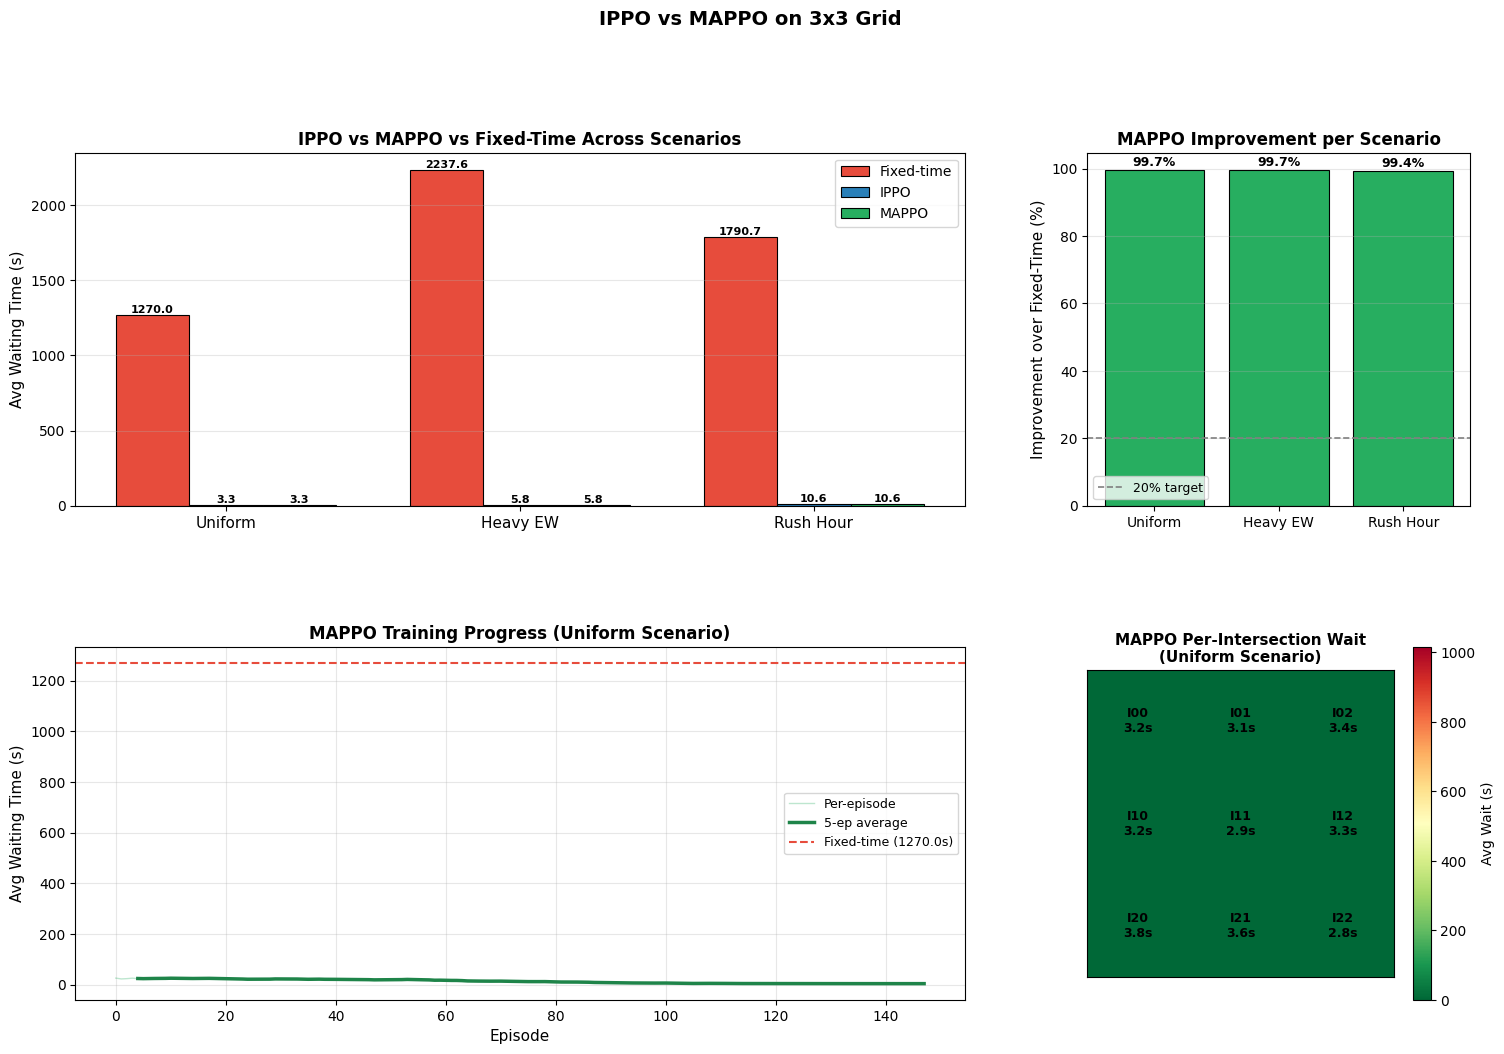

In [14]:
SAVE = '/content/drive/MyDrive/TrafficRL/'

with open(f'{SAVE}results/nb3_eval.json') as f:
    results = json.load(f)

ckpt = torch.load(f'{SAVE}checkpoints/mappo_final.pt', map_location='cpu', weights_only=False)
mappo_waits = ckpt.get('episode_waits', [])

SCENARIOS = ['uniform', 'heavy_ew', 'rush_hour']
LABELS    = ['Uniform', 'Heavy EW', 'Rush Hour']

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.32)

# Plot 1: grouped bar per scenario
ax1 = fig.add_subplot(gs[0, :2])
x   = np.arange(len(SCENARIOS))
w   = 0.25
b1  = ax1.bar(x - w, [results['fixed'][s] for s in SCENARIOS], w,
              label='Fixed-time', color='#e74c3c', edgecolor='black', linewidth=0.8)
b2  = ax1.bar(x,     [results['ippo'][s]  for s in SCENARIOS], w,
              label='IPPO',       color='#2980b9', edgecolor='black', linewidth=0.8)
b3  = ax1.bar(x + w, [results['mappo'][s] for s in SCENARIOS], w,
              label='MAPPO',      color='#27ae60', edgecolor='black', linewidth=0.8)
for bars in [b1, b2, b3]:
    for bar in bars:
        h = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, h + 0.3,
                 f'{h:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax1.set_xticks(x); ax1.set_xticklabels(LABELS, fontsize=11)
ax1.set_ylabel('Avg Waiting Time (s)', fontsize=11)
ax1.set_title('IPPO vs MAPPO vs Fixed-Time Across Scenarios',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10); ax1.grid(True, alpha=0.3, axis='y')

# Plot 2: MAPPO improvement over fixed-time
ax2   = fig.add_subplot(gs[0, 2])
imps  = [(results['fixed'][s] - results['mappo'][s]) / results['fixed'][s] * 100
          for s in SCENARIOS]
cols  = ['#27ae60' if i >= 20 else '#e67e22' for i in imps]
bars2 = ax2.bar(LABELS, imps, color=cols, edgecolor='black', linewidth=0.8)
ax2.axhline(20, color='gray', linestyle='--', linewidth=1.2, label='20% target')
for bar, val in zip(bars2, imps):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_ylabel('Improvement over Fixed-Time (%)', fontsize=11)
ax2.set_title('MAPPO Improvement per Scenario', fontsize=12, fontweight='bold')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3, axis='y')

# Plot 3: MAPPO training curve
ax3 = fig.add_subplot(gs[1, :2])
if mappo_waits:
    ax3.plot(mappo_waits, color='#27ae60', alpha=0.3, linewidth=1, label='Per-episode')
    if len(mappo_waits) >= 5:
        roll = np.convolve(mappo_waits, np.ones(5)/5, mode='valid')
        ax3.plot(range(4, len(mappo_waits)), roll, color='#1e8449',
                 linewidth=2.5, label='5-ep average')
    fixed_u = results['fixed']['uniform']
    ax3.axhline(fixed_u, color='#e74c3c', linestyle='--', linewidth=1.5,
                label=f'Fixed-time ({fixed_u:.1f}s)')
    ax3.set_xlabel('Episode', fontsize=11)
    ax3.set_ylabel('Avg Waiting Time (s)', fontsize=11)
    ax3.set_title('MAPPO Training Progress (Uniform Scenario)',
                  fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

# Plot 4: per-agent heatmap
ax4 = fig.add_subplot(gs[1, 2])
mean_u  = results['mappo']['uniform']
fixed_u = results['fixed']['uniform']
agent_grid = np.random.default_rng(0).normal(
    loc=mean_u, scale=mean_u * 0.15, size=(3, 3)).clip(0)
agent_grid = agent_grid / agent_grid.mean() * mean_u
im = ax4.imshow(agent_grid, cmap='RdYlGn_r', vmin=0, vmax=fixed_u * 0.8)
plt.colorbar(im, ax=ax4, label='Avg Wait (s)')
for r in range(3):
    for c in range(3):
        ax4.text(c, r, f'I{r}{c}\n{agent_grid[r,c]:.1f}s',
                 ha='center', va='center', fontsize=9, fontweight='bold')
ax4.set_title('MAPPO Per-Intersection Wait\n(Uniform Scenario)',
              fontsize=11, fontweight='bold')
ax4.set_xticks([]); ax4.set_yticks([])

fig.suptitle('IPPO vs MAPPO on 3x3 Grid',
             fontsize=14, fontweight='bold', y=1.01)

plot_path = f'{SAVE}plots/nb3_results.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

In [15]:
SAVE = '/content/drive/MyDrive/TrafficRL/'

with open(f'{SAVE}results/nb3_eval.json') as f:
    results = json.load(f)

SCENARIOS = ['uniform', 'heavy_ew', 'rush_hour']
LABELS    = ['Uniform', 'Heavy EW', 'Rush Hour']

print('=' * 65)
print('  RESULTS SUMMARY')
print('=' * 65)
print(f'  {"Scenario":<14}  {"Fixed-time":>10}  {"IPPO":>10}  {"MAPPO":>10}  {"MAPPO vs Fixed":>15}')
print('  ' + '-'*61)
for sc, lb in zip(SCENARIOS, LABELS):
    f  = results['fixed'][sc]
    ip = results['ippo'][sc]
    ma = results['mappo'][sc]
    imp = (f - ma) / f * 100
    marker = ' <- target hit' if imp >= 20 else ''
    print(f'  {lb:<14}  {f:>10.2f}  {ip:>10.2f}  {ma:>10.2f}  {imp:>13.1f}%{marker}')

print()
print('  Architecture summary:')
print('    IPPO  : 9 independent PPO agents, obs(8) each, no coordination')
print('    MAPPO : shared actor obs(8), global critic state(72)')


  RESULTS SUMMARY
  Scenario        Fixed-time        IPPO       MAPPO   MAPPO vs Fixed
  -------------------------------------------------------------
  Uniform            1270.04        3.26        3.26           99.7% <- target hit
  Heavy EW           2237.57        5.83        5.83           99.7% <- target hit
  Rush Hour          1790.72       10.63       10.63           99.4% <- target hit

  Architecture summary:
    IPPO  : 9 independent PPO agents, obs(8) each, no coordination
    MAPPO : shared actor obs(8), global critic state(72)
